## Genetic Algorithm Feature Selection

### Load and Preprocess Data

In [1]:
from matplotlib import pyplot as plt
import numpy as np
import pandas as pd
import random
import joblib

from sklearn import metrics
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder

In [2]:
# Load data in dataframe
train_student_data = pd.read_csv("../data/train.csv")
test_student_data = pd.read_csv("../data/test.csv")

# Drop ID column (redundant)
id_data = test_student_data["id"] # Save ID for submission
train_student_data = train_student_data.drop(columns=["id"])
test_student_data = test_student_data.drop(columns=["id"])

# Make Internet Access Binary (Yes = 1, No =0)
train_student_data["internet_access"] = train_student_data["internet_access"].map({"yes": 1, "no": 0})
test_student_data["internet_access"] = test_student_data["internet_access"].map({"yes": 1, "no": 0})    

# One Hot Encode remaining categorical features
categorical_features = ["gender","course","sleep_quality","study_method","facility_rating","exam_difficulty"]
one_hot_data = train_student_data[categorical_features]

encoder = OneHotEncoder(drop="first", sparse_output=False) # Avoid multicollinearity

one_hot_encoded = encoder.fit_transform(one_hot_data)
one_hot_names = encoder.get_feature_names_out(categorical_features)

# Replace existing categorical rows
train_student_data = pd.concat(
    [train_student_data.drop(columns=categorical_features), pd.DataFrame(one_hot_encoded, columns=one_hot_names)],
    axis=1
)

test_student_data = pd.concat(
    [test_student_data.drop(columns=categorical_features), pd.DataFrame(encoder.transform(test_student_data[categorical_features]), columns=one_hot_names)],
    axis=1
)

# Split features and target
target = "exam_score"
features = list(train_student_data.columns)
features.remove(target)

X = train_student_data[features]
y = train_student_data[target]
X_submission = test_student_data[features]

# Split training data into train/validation (80/20)
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

### Build Initial Population

In [3]:
# Building a population of original linear regression solutions (50 total)

# All Features (Baseline) - All 1s
feature_count = len(features)
baseline = [1] * feature_count

# Build population of similar solutions (Exploitation)
pop = []
pop.append(baseline.copy())

for i in range(10): # Population size of 10
    ind = baseline.copy()

    # Randomly Exclude 10% of features
    for j in range(feature_count):
        if np.random.rand() < 0.1:
            ind[j] = 0 # Feature excluded
    pop.append(ind)


# Build population of random solutions (Exploration)
for i in range(50): # Population size of 40
    ind = []
    for j in range(feature_count):
        ind.append(1 if np.random.rand() > 0.5 else 0) # Randomly include/exclude features with 50% chance
    pop.append(ind)

# print (pop)

### GA Operators

In [4]:
# Calculating fitness of individual
def calculate_fitness(individual):

    # Create modified feature set based on individual's binary feature selection
    # 1 include feature, 0 exclude feature
    ind_X_train = X_train.copy()
    for i, include in enumerate(individual):
        if include == 0:
            ind_X_train.iloc[:, i] = 0 # Exclude feature by setting to 0
    
    # Train linear regression on modified features
    model = LinearRegression()
    model.fit(ind_X_train, y_train)
    
    # Predict and calculate RMSE Score
    y_pred = model.predict(ind_X_train)
    fitness = np.sqrt(metrics.mean_squared_error(y_train, y_pred))
    
    return fitness

In [5]:
# Ranked based selection (Higher fitness = higher chance of selection)
def rank_select (population, fitnesses, selected_count):
    
    # Rank individuals based on fitness
    ranked_ind = np.argsort(fitnesses)

    # Select top individuals
    selected = ranked_ind[:selected_count]
    return [population[i] for i in selected]

In [6]:
# Uniform Crossover (Equal chance to inherit from either parent)
def crossover (p1, p2):
    child = []

    # Child inherits has 50% chance to inherit each feature from either parent
    for i in range(len(p1)):
        child.append(p1[i] if np.random.rand() > 0.5 else p2[i])
    return child

In [7]:
# Encourage Mutation to explore
def mutate(individual, mutation_rate=0.1):

    # Feature has a small chance to be switched
    for i in range(len(individual)):
        if np.random.rand() < mutation_rate:
            individual[i] = 1 - individual[i] # From 0 to 1, or 1 to 0
    return individual

### Run Genetic Algorithm

In [8]:
# Simulate 100 Generations
for gen in range(100):
    
    # Calculate fitness of population
    fitnesses = [calculate_fitness(ind) for ind in pop]

    # Select top 10% of population
    selected = rank_select(pop, fitnesses, selected_count=int(len(pop)*0.1))

    # Using the top % of population, create offspring
    new_pop = []
    while len(new_pop) < len(pop):
        p1, p2 = random.sample(selected, 2)
        child = crossover(p1, p2)
        child = mutate(child)
        new_pop.append(child)
    
    print(f"gen: {gen+1} of 100 complete")

    pop = new_pop

gen: 1 of 100 complete
gen: 2 of 100 complete
gen: 3 of 100 complete
gen: 4 of 100 complete
gen: 5 of 100 complete
gen: 6 of 100 complete
gen: 7 of 100 complete
gen: 8 of 100 complete
gen: 9 of 100 complete
gen: 10 of 100 complete
gen: 11 of 100 complete
gen: 12 of 100 complete
gen: 13 of 100 complete
gen: 14 of 100 complete
gen: 15 of 100 complete
gen: 16 of 100 complete
gen: 17 of 100 complete
gen: 18 of 100 complete
gen: 19 of 100 complete
gen: 20 of 100 complete
gen: 21 of 100 complete
gen: 22 of 100 complete
gen: 23 of 100 complete
gen: 24 of 100 complete
gen: 25 of 100 complete
gen: 26 of 100 complete
gen: 27 of 100 complete
gen: 28 of 100 complete
gen: 29 of 100 complete
gen: 30 of 100 complete
gen: 31 of 100 complete
gen: 32 of 100 complete
gen: 33 of 100 complete
gen: 34 of 100 complete
gen: 35 of 100 complete
gen: 36 of 100 complete
gen: 37 of 100 complete
gen: 38 of 100 complete
gen: 39 of 100 complete
gen: 40 of 100 complete
gen: 41 of 100 complete
gen: 42 of 100 complete
g

Best individual: [1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 0]
Best fitness (RMSE): 9.274000341911746


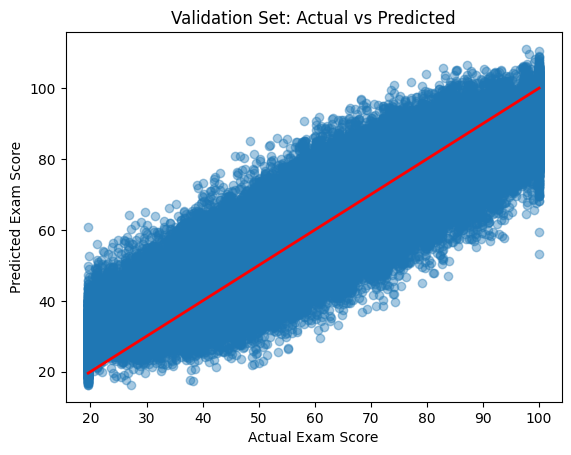

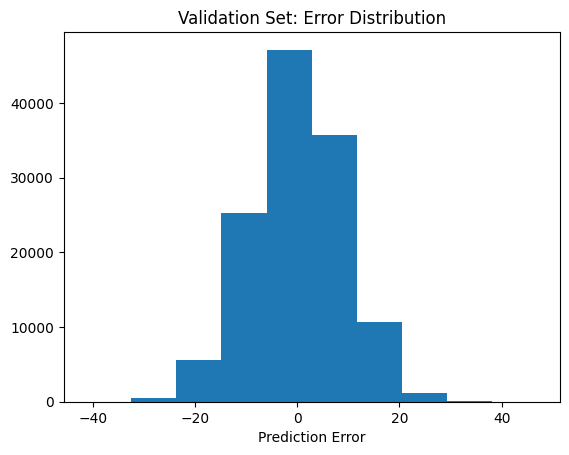

Metrics saved to ../metrics/genetic_algorithm_metrics.csv


,MAE,MSE,RMSE,R2
0,7.093260,78.969714,8.886491,0.777955


In [9]:
# Output the GA results
best_individual = pop[0]
best_fitness = calculate_fitness(best_individual)

# Train on linear regression model with best GA individual features
ga_model = LinearRegression()
ga_model.fit(X_train, y_train)

print("Best individual:", best_individual)
print("Best fitness (RMSE):", best_fitness)

# Evaluate on validation data
y_val_pred = ga_model.predict(X_val)

# Actual vs Predicted
plt.scatter(y_val, y_val_pred, alpha=0.4)
plt.plot([y_val.min(), y_val.max()], [y_val.min(), y_val.max()], "r", lw=2)
plt.xlabel("Actual Exam Score")
plt.ylabel("Predicted Exam Score")
plt.title("Validation Set: Actual vs Predicted")
plt.show()

# Error distribution
plt.hist(y_val - y_val_pred)
plt.xlabel("Prediction Error")
plt.title("Validation Set: Error Distribution")
plt.show()

# Metrics
pd.set_option("float_format", "{:f}".format)
res_metrics = pd.DataFrame({
    "MAE": [metrics.mean_absolute_error(y_val, y_val_pred)],
    "MSE": [metrics.mean_squared_error(y_val, y_val_pred)],
    "RMSE": [np.sqrt(metrics.mean_squared_error(y_val, y_val_pred))],
    "R2": [metrics.r2_score(y_val, y_val_pred)],
})
res_metrics.to_csv("../metrics/genetic_algorithm_metrics.csv", index=False)
print("Metrics saved to ../metrics/genetic_algorithm_metrics.csv")
res_metrics

### Generate Submission

In [10]:
# Generate submission predictions using contest test set
coefficients = np.array(ga_model.coef_)
exam_score = ga_model.intercept_ + X_submission.values.dot(coefficients)

df_ga = pd.DataFrame({
    "id": id_data,
    "exam_score": exam_score
})
df_ga.to_csv("../submission/genetic_algorithm_submission.csv", index=False)
print("Submission saved to ../submission/genetic_algorithm_submission.csv")
df_ga

Submission saved to ../submission/genetic_algorithm_submission.csv


,id,exam_score
0,630000,71.759754
1,630001,69.478246
2,630002,87.469780
3,630003,54.938523
4,630004,47.301788
...,...,...
269995,899995,60.947791
269996,899996,38.887484
269997,899997,89.947095
269998,899998,55.479250


In [11]:
# Save model
joblib.dump(ga_model, "../models/genetic_algorithm.pkl")
print("Model saved to ../models/genetic_algorithm.pkl")

Model saved to ../models/genetic_algorithm.pkl
